Day 2: Data Exploration

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
# .. moves up one directory and to access data
matches = pd.read_csv("../data/raw/results.csv")

## 3. Inspect Dataset

In [ ]:
matches.head()

In [4]:
matches.shape

(49450, 9)

In [5]:
matches.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral'],
      dtype='object')

In [6]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49450 entries, 0 to 49449
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49450 non-null  object 
 1   home_team   49450 non-null  object 
 2   away_team   49450 non-null  object 
 3   home_score  49378 non-null  float64
 4   away_score  49378 non-null  float64
 5   tournament  49450 non-null  object 
 6   city        49450 non-null  object 
 7   country     49450 non-null  object 
 8   neutral     49450 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


In [7]:
matches.describe()

,home_score,away_score
count,49378.000000,49378.000000
mean,1.757321,1.182024
std,1.774398,1.402277
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


## 4. Missing Values

In [8]:
matches.isna().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

## 5. Date Range

In [9]:
matches["date"] = pd.to_datetime(matches["date"])

In [10]:
matches["date"].min(), matches["date"].max()

(Timestamp('1872-11-30 00:00:00'), Timestamp('2026-06-27 00:00:00'))

## 6. Create Result Column

In [11]:
def get_result(row):
    if row["home_score"] > row["away_score"]:
        return "home_win"
    elif row["home_score"] < row["away_score"]:
        return "away_win"
    else:
        return "draw"

matches["result"] = matches.apply(get_result, axis=1)

In [12]:
matches[["home_team", "away_team", "home_score", "away_score", "result"]].head()

,home_team,away_team,home_score,away_score,result
0,Scotland,England,0.0,0.0,draw
1,England,Scotland,4.0,2.0,home_win
2,Scotland,England,2.0,1.0,home_win
3,England,Scotland,2.0,2.0,draw
4,Scotland,England,3.0,0.0,home_win


In [13]:
matches["result"].value_counts()

result
home_win    24199
away_win    13953
draw        11298
Name: count, dtype: int64

## 7. Result Distribution

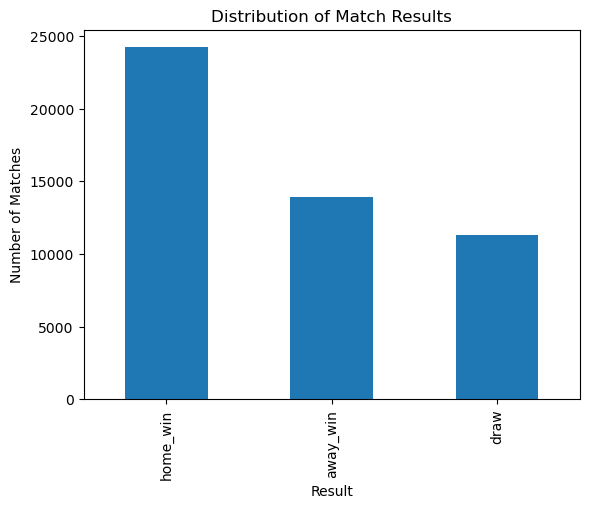

In [14]:
matches["result"].value_counts().plot(kind="bar")

plt.title("Distribution of Match Results")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

## 8. World Cup Matches

In [15]:
world_cup_matches = matches[matches["tournament"] == "FIFA World Cup"]

In [16]:
world_cup_matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result
1490,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,away_win
1491,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True,home_win
1492,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True,away_win
1493,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,away_win
1494,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True,home_win


In [17]:
world_cup_matches.shape

(1036, 10)

In [18]:
world_cup_matches["result"].value_counts()

result
home_win    439
away_win    311
draw        286
Name: count, dtype: int64

## 9. Save Processed Dataset

In [25]:
matches.to_csv("../data/processed/matches_with_results.csv", index=False)